**Title**: Job Monitoring - Admin Version

**Date**:  July 9th 2020

**Description**:  
A simple tutorial about job monitoring for admin only. 

Topics that are included:
1. Jobs that I have launched
2. Filter jobs based on gear name, date range, and state
3. Cancelling Jobs
4. Restarting Jobs
5. Get summary of job status

Capture information about jobs: Execution time, queue time, by job, sorting, plots with information about the job id on hover 

### **Requirements**:
1. Access to a Flywheel instance.
3. A Flywheel API key.
2. A Flywheel Project with ideally the dataset used in the [upload-data notebook](https://gitlab.com/flywheel-io/public/flywheel-tutorials/-/blob/master/python/upload-data-to-a-new-project.ipynb).
2. Site Admin Permission?
3. Have some jobs running in your Flywheel Project

<div class="alert alert-block alert-warning" >
    <b>NOTE:</b> This notebook is using a test dataset provided by the <a href="https://gitlab.com/flywheel-io/public/flywheel-tutorials/-/blob/master/python/upload-data-to-a-new-project.ipynb" style="color:black">upload-data notebook</a>. If you have not uploaded this test dataset yet, we strongly recommend you do so now following steps in <a href="https://gitlab.com/flywheel-io/public/flywheel-tutorials/-/blob/master/python/upload-data-to-a-new-project.ipynb" style="color:black">here</a> before proceeding because this notebook is based on a specific project structure.
</div>

<div class="alert alert-block alert-danger" >
    <b>WARNING:</b> The metadata of the acquisitions in your test project will be updated and new files will be created after running the scripts below. 
</div>

# Install and Import Dependencies

In [ ]:
# Install specific packages required for this notebook
!pip install flywheel-sdk pandas

In [1]:
# Import packages
from getpass import getpass
import logging
import os
import datetime
import pprint
from dateutil.tz import tzutc

from IPython.display import display, Image
import flywheel
from permission import check_user_permission
import numpy as np
from tqdm import tqdm
import statistics as stats
from scipy import stats as st
import matplotlib.pyplot as plt
from scipy.stats import normaltest

In [2]:
# Instantiate a logger
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s')
log = logging.getLogger('root')

# Flywheel API Key and Client

Get a API_KEY. More on this at in the Flywheel SDK doc [here](https://flywheel-io.gitlab.io/product/backend/sdk/branches/master/python/getting_started.html#api-key).

In [3]:
API_KEY = getpass('Enter API_KEY here: ')

Enter API_KEY here:  ····································


Instantiate the Flywheel API client

In [4]:
fw = flywheel.Client(API_KEY or os.environ.get('FW_KEY'))

Show Flywheel logging information

In [5]:
log.info('You are now logged in as %s to %s', fw.get_current_user()['email'], fw.get_config()['site']['api_url'])

2020-07-09 19:31:20,354 INFO You are now logged in as tanxx587@umn.edu to https://ss.ce.flywheel.io:443/api


***

# Check User Minimum Requirements

Before we started our section, we would like to verify that you have the right permission to proceed in this notebook. 


In [ ]:
min_reqs = {
"site": "site_admin",
"group": "ro",
"project": ['jobs_view',
             'jobs_run_cancel',
             'jobs_cancel_any']
}

***

# Find Jobs

Firstly, we will show you how to find the jobs that you have run previously. 

In the example below, we will be getting 2 jobs that you have launched within your instance. You can change the number of jobs that will be returned by modified the `limit` variable.

In [16]:
user_id = fw.get_current_user()['email']

In [31]:
user_jobs = fw.jobs.find(f'origin.id={user_id}',limit = '2')

In [ ]:
pprint.pprint(user_jobs)

<div class="alert alert-block alert-info" style="color:black"><b>Info:</b>To learn more about the different attributes, please visit our SDK Docs <a href="https://flywheel-io.gitlab.io/product/backend/sdk/branches/master/python/flywheel.models.html?highlight=job#module-flywheel.models.job">here</a>. It will come in handy when you try to filter jobs.</div>

Essentially, you can search for the jobs that launched by other users as well. 


In [20]:
sample_id = input('Please enter the user\'s email address that you wished to search for:  ')

Please enter the user's email address that you wished to search for:   


In [ ]:
user_jobs = fw.jobs.find(f'origin.id={sample_id}',limit = '2')

In [ ]:
pprint.pprint(user_jobs)

***

# Filter jobs based on gear name, date range, and state

## Gear Name

In [23]:
gear_name = 'mriqc'

In [ ]:
mriqc_jobs = fw.jobs.find(f'gear_info.name={gear_name}', limit='2')


In [ ]:
pprint.pprint(mriqc_jobs)

## Date Range

In [28]:
created_by = '2020-07-01'

In [29]:
filtered_jobs = fw.jobs.find(f'created>{created_by}', limit='2')

In [ ]:
pprint.pprint(filtered_jobs)

## State

In [ ]:
state = 'complete'

In [ ]:
filtered_jobs = fw.jobs.find(f'state={state}', limit='2')

In [ ]:
pprint.pprint(filtered_jobs)

***

# Cancel Jobs

***

# Restart Jobs

***

# Statistics of the Jobs

In this section, we will be presenting some use case of job statsitcis or informations that you can plot them into graph. *NEED TO ADD MORE CONTENT IN HERE*



## Initialize a few values

In [ ]:
def validate(date_text):
    try:
        datetime.datetime.strptime(date_text, '%Y-%m-%d')
    except ValueError:
        raise ValueError("Incorrect data format, should be YYYY-MM-DD")

In [74]:
GEAR_NAME = input('Please enter the gear that you wish to print out the information about: ')
CREATED_BY = input('Please enter the date you wish to filter by in this format (yyyy-mm-dd): ')
MAX_SAMPLE_SIZE = input('Please enter the max number of jobs you want to analyze: ')
JOB_STATUS = input('Please enter the job status that you would like to filter by: ')

Please enter the gear that you wish to print out the information about:  mriqc
Please enter the date you wish to filter by in this format (yyyy-mm-dd):  2019-05-10
Please enter the max number of jobs you want to analyze:  1000
Please enter the job status that you would like to filter by:  failed


In [ ]:
# Verify if you have entered the right date format
validate(CREATED_BY)

In [41]:
type(MAX_SAMPLE_SIZE)

str

In [66]:
try1 = int(MAX_SAMPLE_SIZE)

## Helpful Function

In [75]:
for job in fw.jobs.find(f'gear_info.name={GEAR_NAME}, state={JOB_STATUS}, created>{CREATED_BY}', limit= 1000):
    print(job.id)

In [62]:
def plot(fw_client, gear_name,job_status, created_by, sample_size):
    run_times = list()
    
    for job in tqdm(fw_client.jobs.find(f'gear_info.name={gear_name}, state={job_status}, created>{created_by}, limit={sample_size}')):
        job_container = fw.get_job(job.id)
        time_delta = job.transitions.comple = job.transitions.running
        run_times.append(time_delta.total_seconds()/60)
        
    if len(run_times)<=int(sample_size):
        plt.hist(run_times)
        plt.title(f'{gear_name} run times in minutes')
        plt.show()

0it [00:00, ?it/s]


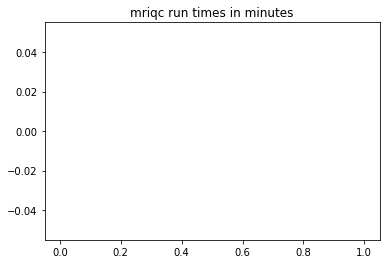

In [63]:
plot(fw, GEAR_NAME, JOB_STATUS, CREATED_BY, MAX_SAMPLE_SIZE)

0it [00:00, ?it/s]


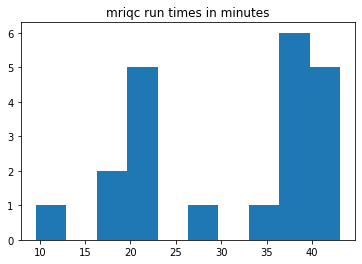

In [52]:
for j in tqdm(fw.jobs.find(f'status={JOB_STATUS}, limit={MAX_SAMPLE_SIZE}')):
    job = fw.get_job(j.id)
    time_delta = job.transitions.complete - job.transitions.running
    run_times.append(time_delta.total_seconds()/60)

if plot:
    plt.hist(run_times)
    plt.title("{} run times in minutes".format(gear_name))
    plt.show()


100%|██████████| 21/21 [00:01<00:00, 14.77it/s]


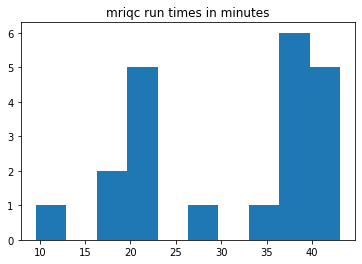

In [51]:
gear_name = 'mriqc'
created_post = '2019-10-30'
sample_size_max = 1000
plot = True

run_times = list()

for j in tqdm(fw.jobs.find('gear_info.name={},state=complete,created>{}'.format(gear_name, created_post), limit=sample_size_max)):
    job = fw.get_job(j.id)
    time_delta = job.transitions.complete - job.transitions.running
    run_times.append(time_delta.total_seconds()/60)

if plot:
    plt.hist(run_times)
    plt.title("{} run times in minutes".format(gear_name))
    plt.show()

In [54]:
fw.jobs.find('gear_info.name={},state=complete,created>{}'.format(gear_name, created_post), limit=1)

[{'attempt': 1,
  'config': {'config': {'measurement': 'auto-detect',
                        'save_derivatives': False,
                        'save_outputs': False,
                        'verbose_reports': False},
             'destination': {'id': '5df7fbfca6b543f6679e6270',
                             'type': 'acquisition'},
             'inputs': {'nifti': {'base': 'file',
                                  'hierarchy': {'id': '5df7fbfca6b543f6679e6270',
                                                'type': 'acquisition'},
                                  'location': {'name': 'T1w_MPR.nii.gz',
                                               'path': '/flywheel/v0/input/nifti/T1w_MPR.nii.gz'},
                                  'object': {'classification': {'Intent': ['Structural'],
                                                                'Measurement': ['T1']},
                                             'measurements': ['Structural',
                                   